In [36]:
from sklearn.datasets import fetch_california_housing
import pandas as pd 
data = fetch_california_housing(as_frame= True )
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Overview

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [38]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


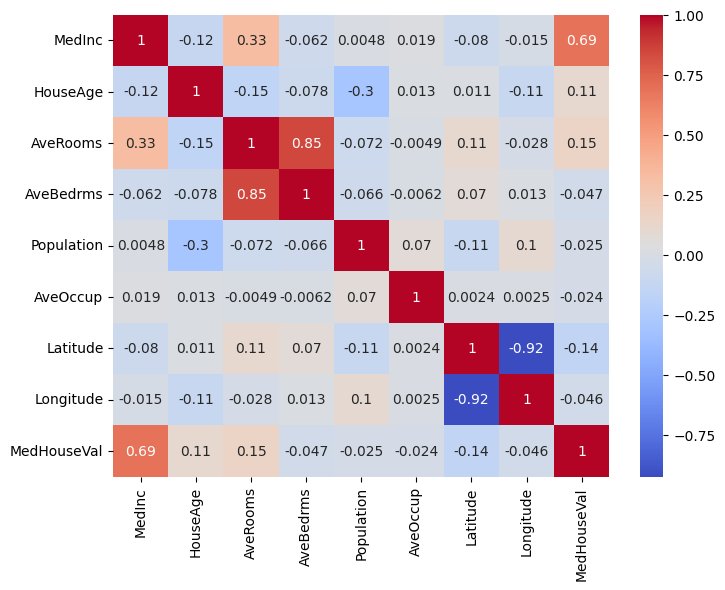

In [39]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr() , annot =True ,cmap= "coolwarm")
plt.show()

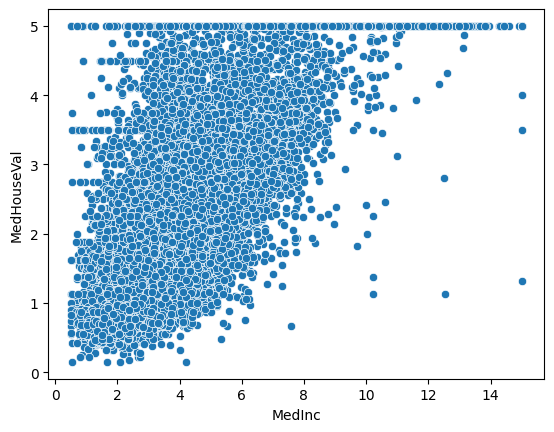

In [40]:
sns.scatterplot(x= "MedInc" , y = "MedHouseVal" , data= df)
plt.show()

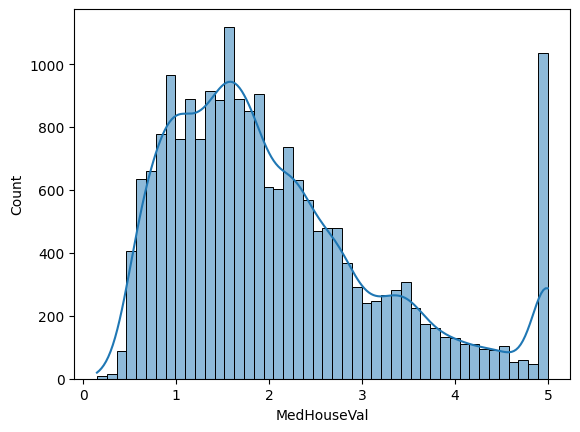

In [41]:
sns.histplot(df["MedHouseVal"] , kde= True)
plt.show()

## model

In [42]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error , r2_score

X = df.drop("MedHouseVal" , axis= 1)
y = df["MedHouseVal"]

x_train , x_test , y_train , y_test = train_test_split(X ,y, train_size= 0.8 , random_state= 42 , shuffle= True)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = RandomForestRegressor(n_estimators= 500 ,max_depth= 15 , min_samples_split=8 ,min_samples_leaf= 3 , random_state= 42)
model.fit(x_train , y_train)
y_pred_t = model.predict(x_train)
y_pred_ts = model.predict(x_test)




## Evaluation

In [43]:
import numpy as np 

MSE_train = mean_squared_error(y_train , y_pred_t)
MSE_test = mean_squared_error(y_test , y_pred_ts)

RMSE_train = np.sqrt(MSE_train)
RMSE_test = np.sqrt(MSE_test)

R2_train = r2_score(y_train, y_pred_t)
R2_test = r2_score(y_test, y_pred_ts)

print("Train MSE:", MSE_train)
print("Test MSE:", MSE_test)
print("Train RMSE:", RMSE_train)
print("Test RMSE:", RMSE_test)
print("Train R²:", R2_train)
print("Test R²:", R2_test)

Train MSE: 0.09868778125038292
Test MSE: 0.2596519918280132
Train RMSE: 0.31414611449193974
Test RMSE: 0.5095605870041493
Train R²: 0.9261749029270321
Test R²: 0.801854233190182
